# 0.0 Initial setting
## 0.1 Python's Libraries Imports

In [1]:
import mysql.connector
import pandas as pd
import numpy as np

from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats.mstats import winsorize

## 0.2 SQL connection and Data Import

In [2]:
host = "212.227.148.202"
user = "Equipo32"
password = "E1q2u3i4p5o32"
db = "Equip_32"

connection = mysql.connector.connect(
    host=host,
    user=user,
    password=password,
    database=db
)

if connection.is_connected():
    print("Conexión exitosa")

query = """
SELECT *
FROM BANK_marketing;
"""

df = pd.read_sql(query, connection)

df.head()

Conexión exitosa


C:\Users\elisa\AppData\Local\Temp\ipykernel_22876\2909874624.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,1,59.0,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,2,56.0,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,3,41.0,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,4,55.0,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,5,54.0,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


## 0.3 Hue Style

In [3]:
# General graph style

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11

# 1. Data Undestanding

## 1.1 Basic exploration

In [4]:
df.shape

(10987, 18)

In [5]:
df.columns

Index(['id', 'age', 'job', 'marital', 'education', 'default', 'balance',
       'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign',
       'pdays', 'previous', 'poutcome', 'deposit'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10987 entries, 0 to 10986
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         10987 non-null  int64  
 1   age        10977 non-null  float64
 2   job        10987 non-null  str    
 3   marital    10982 non-null  str    
 4   education  10980 non-null  str    
 5   default    10987 non-null  str    
 6   balance    10987 non-null  int64  
 7   housing    10987 non-null  str    
 8   loan       10987 non-null  str    
 9   contact    10987 non-null  str    
 10  day        10987 non-null  int64  
 11  month      10987 non-null  str    
 12  duration   10987 non-null  int64  
 13  campaign   10987 non-null  int64  
 14  pdays      10987 non-null  int64  
 15  previous   10987 non-null  int64  
 16  poutcome   10987 non-null  str    
 17  deposit    10987 non-null  str    
dtypes: float64(1), int64(7), str(10)
memory usage: 2.0 MB


In [7]:
connection.close()

In [8]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
})

missing[missing["missing_count"] > 0]

,missing_count,missing_percent
age,10,0.09
marital,5,0.05
education,7,0.06


In [9]:
# ver que filas tienen nulos
df[df.isna().any(axis=1)]

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
1088,1089,53.0,management,NaN,secondary,no,1004,no,yes,telephone,22,dec,119,1,-1,0,unknown,yes
1181,1182,NaN,management,married,tertiary,no,309,yes,no,cellular,5,feb,676,1,-1,0,unknown,yes
1300,1301,37.0,technician,married,NaN,no,549,no,no,cellular,2,mar,239,1,-1,0,unknown,yes
1410,1411,NaN,blue-collar,married,primary,no,4979,no,no,telephone,6,apr,180,1,-1,0,unknown,yes
2943,2944,24.0,student,single,NaN,no,382,no,no,cellular,13,nov,256,2,92,3,failure,yes
3719,3720,68.0,retired,NaN,secondary,no,4189,no,no,telephone,14,jul,897,2,-1,0,unknown,yes
4019,4020,NaN,services,single,secondary,no,1934,no,no,cellular,29,sep,271,1,-1,0,unknown,yes
4737,4738,37.0,management,single,NaN,no,102,yes,no,cellular,6,may,445,1,258,2,failure,yes
4854,4855,34.0,management,NaN,tertiary,no,5,no,no,cellular,18,aug,370,2,-1,0,unknown,yes
5680,5681,NaN,technician,single,tertiary,no,720,no,no,cellular,12,aug,234,4,-1,0,unknown,no


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df["id"].duplicated().sum()

np.int64(0)

## 1.2 Data description

In [12]:
df.describe()

,id,age,balance,day,duration,campaign,pdays,previous
count,10987.000000,10977.000000,10987.000000,10987.000000,10987.000000,10987.000000,10987.000000,10987.000000
mean,5494.000000,41.263004,1538.162738,15.651952,374.183763,2.505233,51.659052,0.838810
std,3171.818038,11.952308,3240.007771,8.424481,348.493183,2.725176,109.033750,2.302484
min,1.000000,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,2747.500000,32.000000,125.000000,8.000000,139.000000,1.000000,-1.000000,0.000000
50%,5494.000000,39.000000,556.000000,15.000000,256.000000,2.000000,-1.000000,0.000000
75%,8240.500000,49.000000,1723.000000,22.000000,501.000000,3.000000,40.000000,1.000000
max,10987.000000,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [13]:
df["deposit"].value_counts()

deposit
no     5698
yes    5289
Name: count, dtype: int64

In [14]:
df.describe(include="all")

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
count,10987.000000,10977.000000,10987,10982,10980,10987,10987.000000,10987,10987,10987,10987.000000,10987,10987.000000,10987.000000,10987.000000,10987.000000,10987,10987
unique,NaN,NaN,12,3,4,2,NaN,2,2,3,NaN,12,NaN,NaN,NaN,NaN,4,2
top,NaN,NaN,management,married,secondary,no,NaN,no,no,cellular,NaN,may,NaN,NaN,NaN,NaN,unknown,no
freq,NaN,NaN,2535,6237,5387,10826,NaN,5804,9556,7928,NaN,2765,NaN,NaN,NaN,NaN,8176,5698
mean,5494.000000,41.263004,NaN,NaN,NaN,NaN,1538.162738,NaN,NaN,NaN,15.651952,NaN,374.183763,2.505233,51.659052,0.838810,NaN,NaN
std,3171.818038,11.952308,NaN,NaN,NaN,NaN,3240.007771,NaN,NaN,NaN,8.424481,NaN,348.493183,2.725176,109.033750,2.302484,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,NaN,-6847.000000,NaN,NaN,NaN,1.000000,NaN,2.000000,1.000000,-1.000000,0.000000,NaN,NaN
25%,2747.500000,32.000000,NaN,NaN,NaN,NaN,125.000000,NaN,NaN,NaN,8.000000,NaN,139.000000,1.000000,-1.000000,0.000000,NaN,NaN
50%,5494.000000,39.000000,NaN,NaN,NaN,NaN,556.000000,NaN,NaN,NaN,15.000000,NaN,256.000000,2.000000,-1.000000,0.000000,NaN,NaN
75%,8240.500000,49.000000,NaN,NaN,NaN,NaN,1723.000000,NaN,NaN,NaN,22.000000,NaN,501.000000,3.000000,40.000000,1.000000,NaN,NaN


In [15]:
categoricas = df.select_dtypes(include="object").columns

for col in categoricas:
    print()
    print(df[col].value_counts())


job
management       2535
blue-collar      1905
technician       1793
admin.           1318
services          906
retired           770
self-employed     398
student           359
unemployed        346
entrepreneur      320
housemaid         267
unknown            70
Name: count, dtype: int64

marital
married     6237
single      3472
divorced    1273
Name: count, dtype: int64

education
secondary    5387
tertiary     3638
primary      1468
unknown       487
Name: count, dtype: int64

default
no     10826
yes      161
Name: count, dtype: int64

housing
no     5804
yes    5183
Name: count, dtype: int64

loan
no     9556
yes    1431
Name: count, dtype: int64

contact
cellular     7928
unknown      2295
telephone     764
Name: count, dtype: int64

month
may    2765
aug    1495
jul    1487
jun    1209
nov     926
apr     912
feb     764
oct     390
jan     338
sep     316
mar     275
dec     110
Name: count, dtype: int64

poutcome
unknown    8176
failure    1212
success    1069
other     

C:\Users\elisa\AppData\Local\Temp\ipykernel_9152\3651939843.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = df.select_dtypes(include="object").columns


## 1.3 Data distribution

array([[<Axes: title={'center': 'id'}>, <Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'balance'}>],
       [<Axes: title={'center': 'day'}>,
        <Axes: title={'center': 'duration'}>,
        <Axes: title={'center': 'campaign'}>],
       [<Axes: title={'center': 'pdays'}>,
        <Axes: title={'center': 'previous'}>, <Axes: >]], dtype=object)

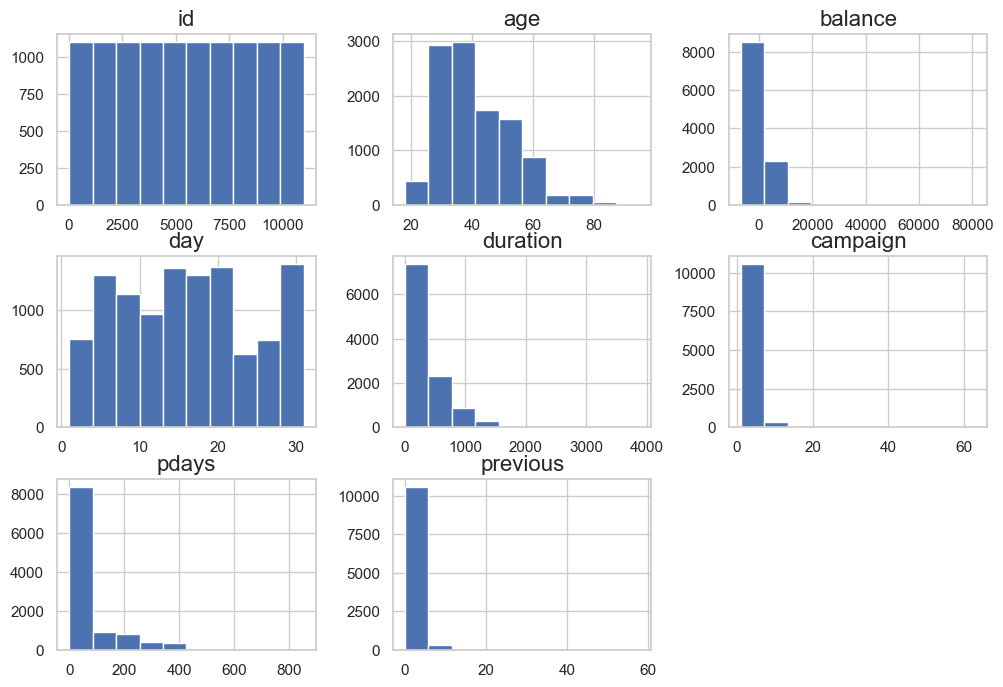

In [16]:
df.hist(figsize=(12,8))

In [17]:
df.corr(numeric_only=True)

,id,age,balance,day,duration,campaign,pdays,previous
id,1.000000,-0.015857,-0.047746,0.041622,-0.456444,0.099569,-0.069310,-0.066229
age,-0.015857,1.000000,0.111549,-0.000832,-0.000994,-0.006066,0.002954,0.020967
balance,-0.047746,0.111549,1.000000,0.010785,0.020755,-0.013727,0.017209,0.030671
day,0.041622,-0.000832,0.010785,1.000000,-0.018829,0.135042,-0.075820,-0.057722
duration,-0.456444,-0.000994,0.020755,-0.018829,1.000000,-0.040329,-0.027890,-0.027184
campaign,0.099569,-0.006066,-0.013727,0.135042,-0.040329,1.000000,-0.102728,-0.049848
pdays,-0.069310,0.002954,0.017209,-0.075820,-0.027890,-0.102728,1.000000,0.506451
previous,-0.066229,0.020967,0.030671,-0.057722,-0.027184,-0.049848,0.506451,1.000000


In [4]:
#  Export dataset to csv post understanding 

# Create output directory if it doesn't exist
output_dir = Path("../Data")
output_dir.mkdir(parents=True, exist_ok=True)

# Export dataframe
output_file = output_dir / "2026-07-06_bank_dataset_raw.csv"
df.to_csv(output_file, index=False, encoding="utf-8")

print(f"CSV saved to: {output_file.resolve()}")

CSV saved to: C:\Users\elisa\Documents\Simulador\ProjecteData\Equip_32\Data\2026-07-06_bank_dataset_raw.csv


El nuevo dataset incorpora 345 registros adicionales, pasando de 10.642 a 10.987 observaciones, sin modificar la estructura de las variables. Todos los nuevos registros pertenecen a la categoría deposit = "no", mientras que el número de clientes con deposit = "yes" permanece constante. Como consecuencia, la distribución de la variable objetivo deja de estar prácticamente equilibrada y pasa a presentar un mayor peso de la clase "no". Este cambio deberá tenerse en cuenta durante el análisis, ya que podría influir en la segmentación y en los resultados obtenidos. 
Los 345 registros incorporados presentan una duración media de llamada inferior a la observada en el conjunto original (235 s frente a 378 s). Este comportamiento es coherente con la distribución de la variable objetivo, ya que las llamadas de menor duración suelen asociarse a una menor probabilidad de contratación del depósito.